In [2]:
import torch

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [3]:
random_seed = 69
torch.manual_seed(random_seed)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])



full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


print("Original training images:", len(full_train_dataset))
print("Testing images:", len(test_dataset))
print("Digit classes:", full_train_dataset.classes)

100.0%
100.0%
100.0%
100.0%

Original training images: 60000
Testing images: 10000
Digit classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [4]:
train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(random_seed)
)


print("\nTraining images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Testing images:", len(test_dataset))


Training images: 50000
Validation images: 10000
Testing images: 10000


In [5]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


images, labels = next(iter(train_loader))

print("\nImage batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])


Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
First 10 labels: tensor([6, 1, 3, 1, 5, 1, 8, 2, 4, 3])


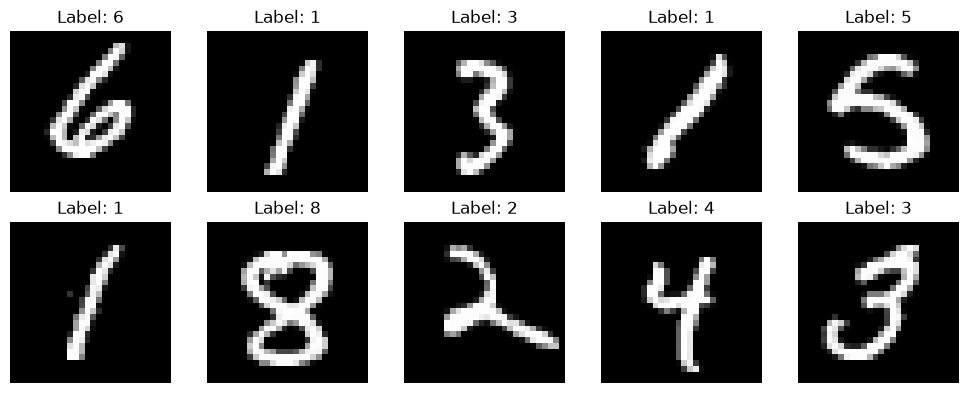

In [7]:
def denormalize(image):
    return image * 0.3081 + 0.1307


figure = plt.figure(figsize=(10, 4))

for index in range(10):
    image = denormalize(images[index])

    plt.subplot(2, 5, index + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {labels[index].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()